In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import shutil

# Source directories
train_dir = "/kaggle/input/alzheimer-diseases-3-class/3_cls/train"
test_dir = "/kaggle/input/alzheimer-diseases-3-class/3_cls/test"

# Target directory
merged_dir = "/kaggle/working/merged_dataset"
os.makedirs(merged_dir, exist_ok=True)

# Function to copy images maintaining class subfolders
def copy_images(src_dir, dst_dir):
    for class_name in os.listdir(src_dir):
        class_src_path = os.path.join(src_dir, class_name)
        class_dst_path = os.path.join(dst_dir, class_name)
        os.makedirs(class_dst_path, exist_ok=True)
        for img_name in os.listdir(class_src_path):
            src_img_path = os.path.join(class_src_path, img_name)
            dst_img_path = os.path.join(class_dst_path, img_name)
            if not os.path.exists(dst_img_path):  # avoid overwriting
                shutil.copy(src_img_path, dst_img_path)

# Copy train and test images to merged folder
copy_images(train_dir, merged_dir)
copy_images(test_dir, merged_dir)

print(f"Merged dataset created at: {merged_dir}")


Merged dataset created at: /kaggle/working/merged_dataset


In [2]:
import os
import shutil
from torchvision import datasets
from sklearn.model_selection import train_test_split

# Define the path to the original dataset and the new directory to save the splits
dataset_dir = '/kaggle/working/merged_dataset'
output_dir = '/kaggle/working/split_dataset'

# Create output directories for train, validation, and test splits
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')

# Make sure the directories exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Load the dataset using ImageFolder
dataset = datasets.ImageFolder(root=dataset_dir)

# Create a split for 80% training, 10% validation, and 10% test using sklearn's train_test_split
# Split images and labels
image_paths = [img_path for img_path, _ in dataset.imgs]
labels = [label for _, label in dataset.imgs]

# First split (train + val/test)
train_paths, val_test_paths, train_labels, val_test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42)

# Second split (val + test)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    val_test_paths, val_test_labels, test_size=0.5, stratify=val_test_labels, random_state=42)

# Function to move images to the corresponding folder
def move_images(image_paths, labels, folder):
    for path, label in zip(image_paths, labels):
        class_name = dataset.classes[label]
        class_dir = os.path.join(folder, class_name)
        os.makedirs(class_dir, exist_ok=True)
        shutil.copy(path, os.path.join(class_dir, os.path.basename(path)))

# Move the files to their respective directories
move_images(train_paths, train_labels, train_dir)
move_images(val_paths, val_labels, val_dir)
move_images(test_paths, test_labels, test_dir)

# Verify that the directories are created and files are moved
print(f"Training set saved to: {train_dir}")
print(f"Validation set saved to: {val_dir}")
print(f"Testing set saved to: {test_dir}")


Training set saved to: /kaggle/working/split_dataset/train
Validation set saved to: /kaggle/working/split_dataset/val
Testing set saved to: /kaggle/working/split_dataset/test



==== Training VGG16 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 183MB/s]  


Epoch 1/15 | Train Loss: 0.5355 | Train Acc: 0.7326 | Val Loss: 0.5809 | Val Acc: 0.6920 | Test Loss: 0.5589 | Test Acc: 0.7255
Epoch 2/15 | Train Loss: 0.4275 | Train Acc: 0.8032 | Val Loss: 0.5345 | Val Acc: 0.7371 | Test Loss: 0.4996 | Test Acc: 0.7577
Epoch 3/15 | Train Loss: 0.3529 | Train Acc: 0.8412 | Val Loss: 0.4757 | Val Acc: 0.7861 | Test Loss: 0.4297 | Test Acc: 0.8003
Epoch 4/15 | Train Loss: 0.2882 | Train Acc: 0.8743 | Val Loss: 0.4169 | Val Acc: 0.8222 | Test Loss: 0.3623 | Test Acc: 0.8415
Epoch 5/15 | Train Loss: 0.2346 | Train Acc: 0.9039 | Val Loss: 0.3057 | Val Acc: 0.8724 | Test Loss: 0.2947 | Test Acc: 0.8827
Epoch 6/15 | Train Loss: 0.1802 | Train Acc: 0.9281 | Val Loss: 0.3933 | Val Acc: 0.8505 | Test Loss: 0.3137 | Test Acc: 0.8557
Epoch 7/15 | Train Loss: 0.1513 | Train Acc: 0.9436 | Val Loss: 0.2359 | Val Acc: 0.8969 | Test Loss: 0.1827 | Test Acc: 0.9201
Epoch 8/15 | Train Loss: 0.1105 | Train Acc: 0.9558 | Val Loss: 0.2522 | Val Acc: 0.9059 | Test Loss: 0.

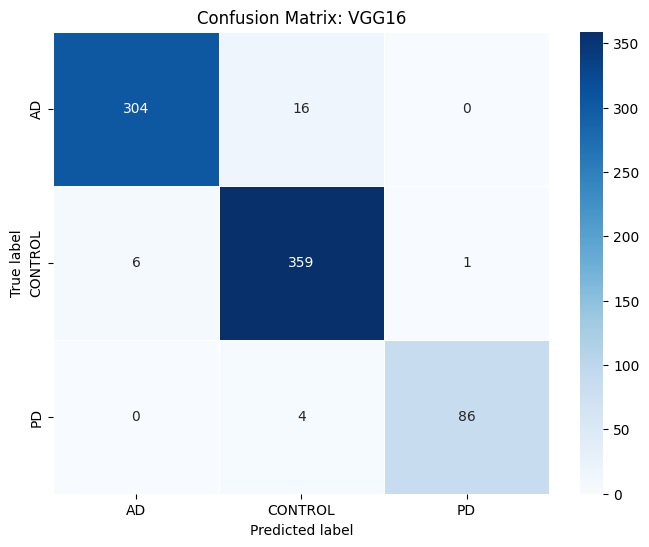

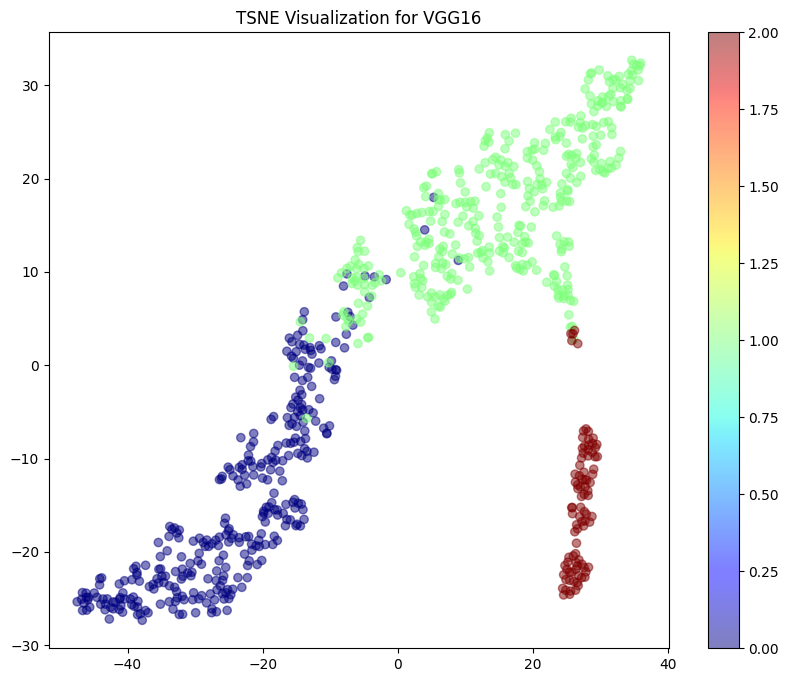

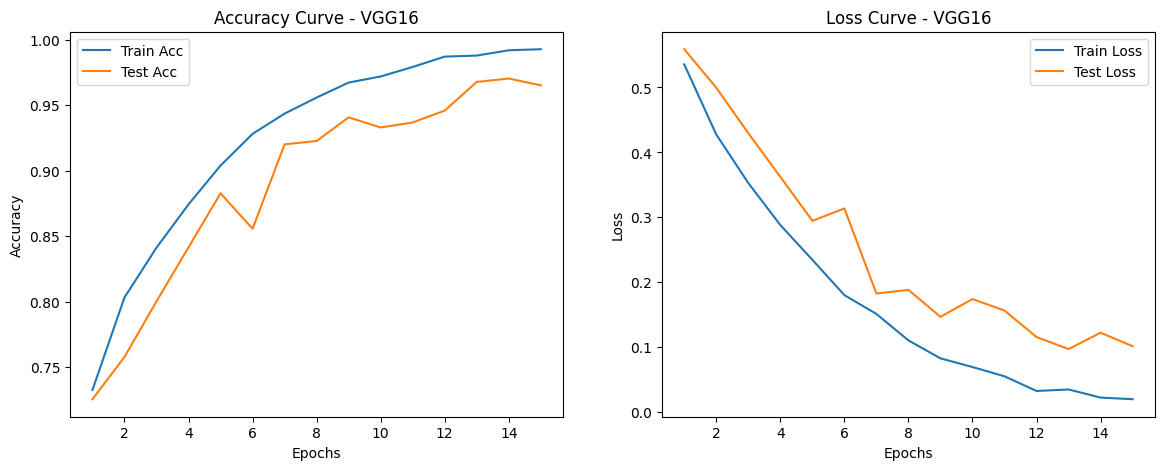


==== Training ResNet18 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s] 


Epoch 1/15 | Train Loss: 0.4984 | Train Acc: 0.7624 | Val Loss: 0.5222 | Val Acc: 0.7526 | Test Loss: 0.4886 | Test Acc: 0.7680
Epoch 2/15 | Train Loss: 0.3794 | Train Acc: 0.8354 | Val Loss: 0.4714 | Val Acc: 0.7796 | Test Loss: 0.4394 | Test Acc: 0.8093
Epoch 3/15 | Train Loss: 0.3341 | Train Acc: 0.8575 | Val Loss: 0.4376 | Val Acc: 0.8093 | Test Loss: 0.3852 | Test Acc: 0.8363
Epoch 4/15 | Train Loss: 0.2882 | Train Acc: 0.8725 | Val Loss: 0.4592 | Val Acc: 0.7951 | Test Loss: 0.3992 | Test Acc: 0.8209
Epoch 5/15 | Train Loss: 0.2382 | Train Acc: 0.9057 | Val Loss: 0.3793 | Val Acc: 0.8338 | Test Loss: 0.3066 | Test Acc: 0.8789
Epoch 6/15 | Train Loss: 0.1963 | Train Acc: 0.9199 | Val Loss: 0.3153 | Val Acc: 0.8557 | Test Loss: 0.2738 | Test Acc: 0.8827
Epoch 7/15 | Train Loss: 0.1661 | Train Acc: 0.9347 | Val Loss: 0.2543 | Val Acc: 0.8879 | Test Loss: 0.2288 | Test Acc: 0.9137
Epoch 8/15 | Train Loss: 0.1331 | Train Acc: 0.9502 | Val Loss: 0.2280 | Val Acc: 0.9059 | Test Loss: 0.

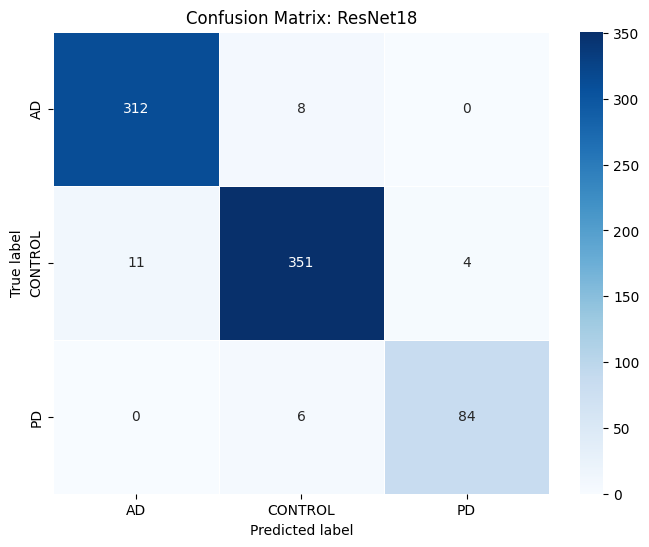

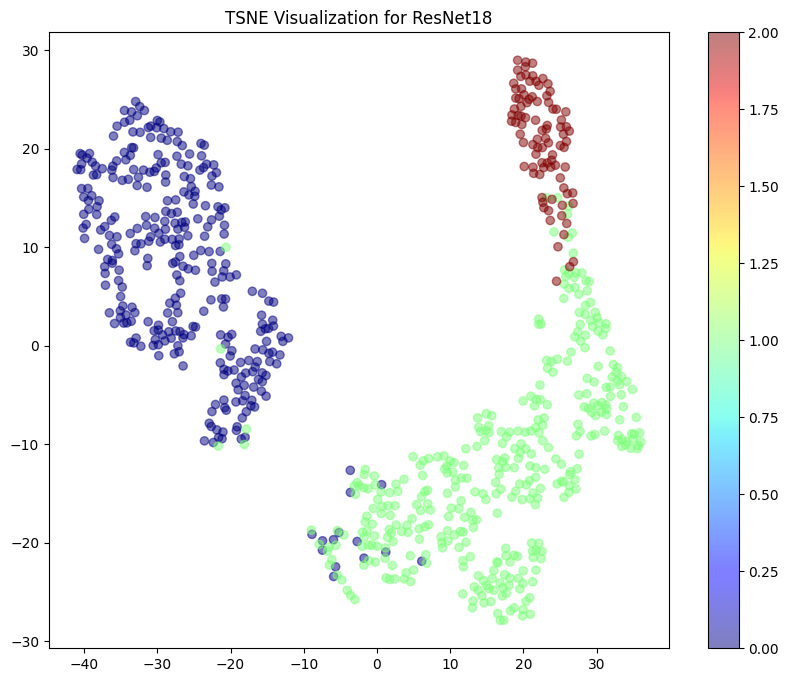

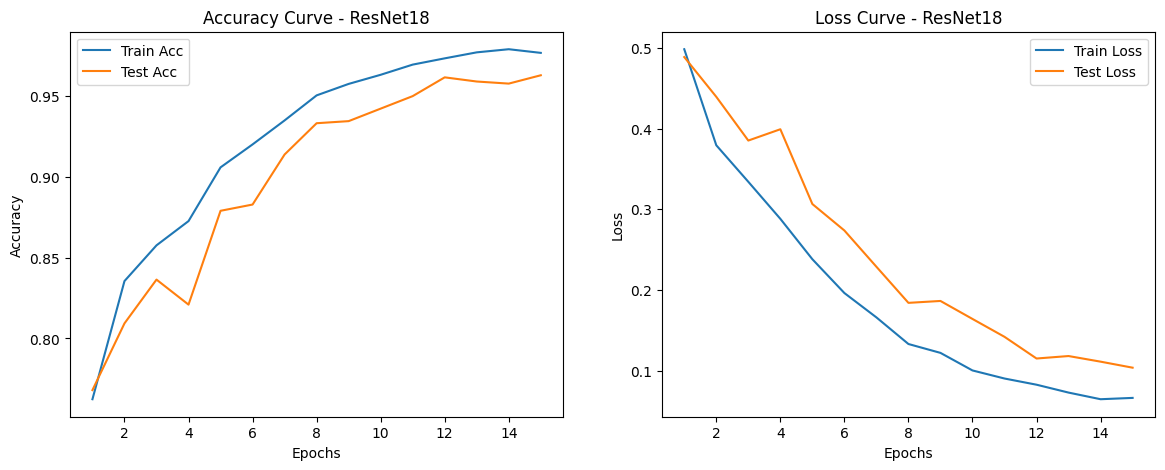


==== Training ResNet50 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


Epoch 1/15 | Train Loss: 0.4767 | Train Acc: 0.7832 | Val Loss: 0.4790 | Val Acc: 0.7822 | Test Loss: 0.4166 | Test Acc: 0.8106
Epoch 2/15 | Train Loss: 0.3519 | Train Acc: 0.8474 | Val Loss: 0.4550 | Val Acc: 0.8054 | Test Loss: 0.4042 | Test Acc: 0.8170
Epoch 3/15 | Train Loss: 0.2730 | Train Acc: 0.8859 | Val Loss: 0.3556 | Val Acc: 0.8479 | Test Loss: 0.3086 | Test Acc: 0.8673
Epoch 4/15 | Train Loss: 0.2103 | Train Acc: 0.9184 | Val Loss: 0.3089 | Val Acc: 0.8724 | Test Loss: 0.2853 | Test Acc: 0.8879
Epoch 5/15 | Train Loss: 0.1797 | Train Acc: 0.9289 | Val Loss: 0.2194 | Val Acc: 0.9175 | Test Loss: 0.1864 | Test Acc: 0.9149
Epoch 6/15 | Train Loss: 0.1354 | Train Acc: 0.9484 | Val Loss: 0.2240 | Val Acc: 0.9149 | Test Loss: 0.2164 | Test Acc: 0.9201
Epoch 7/15 | Train Loss: 0.1081 | Train Acc: 0.9586 | Val Loss: 0.1952 | Val Acc: 0.9149 | Test Loss: 0.1891 | Test Acc: 0.9278
Epoch 8/15 | Train Loss: 0.0880 | Train Acc: 0.9711 | Val Loss: 0.1563 | Val Acc: 0.9407 | Test Loss: 0.

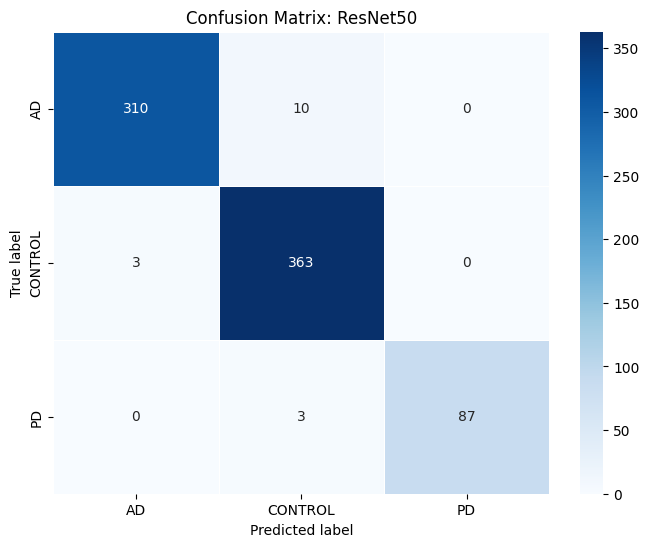

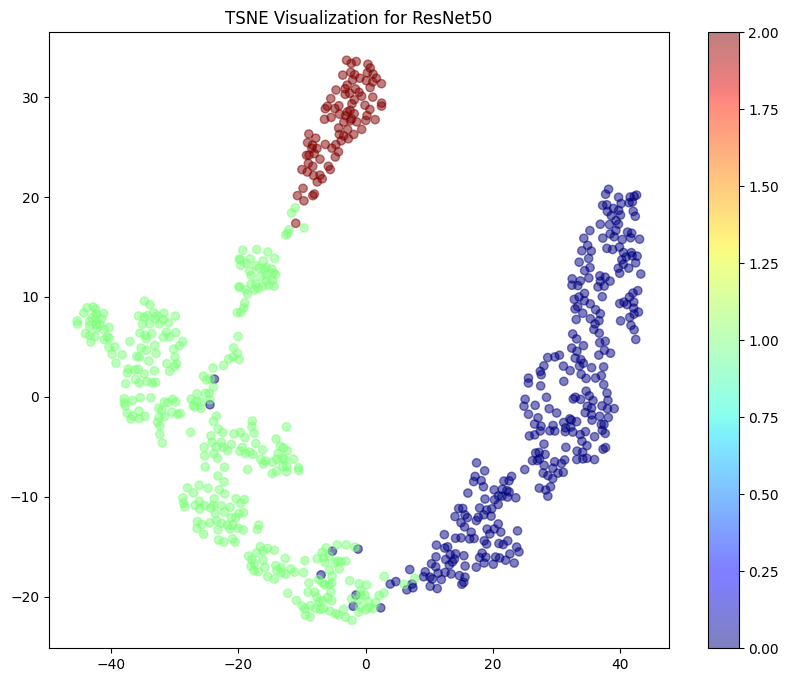

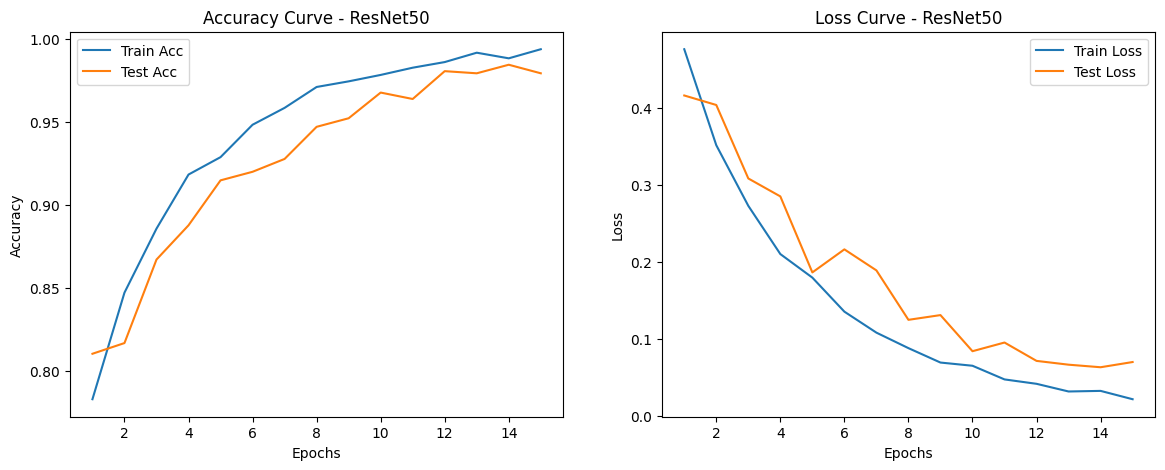


==== Training EfficientNetB3 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 71.0MB/s]


Epoch 1/15 | Train Loss: 0.7018 | Train Acc: 0.6900 | Val Loss: 0.6927 | Val Acc: 0.6804 | Test Loss: 0.6827 | Test Acc: 0.6869
Epoch 2/15 | Train Loss: 0.5048 | Train Acc: 0.7737 | Val Loss: 0.6047 | Val Acc: 0.7204 | Test Loss: 0.5785 | Test Acc: 0.7165
Epoch 3/15 | Train Loss: 0.4732 | Train Acc: 0.7790 | Val Loss: 0.5562 | Val Acc: 0.7332 | Test Loss: 0.5368 | Test Acc: 0.7461
Epoch 4/15 | Train Loss: 0.4296 | Train Acc: 0.8059 | Val Loss: 0.5258 | Val Acc: 0.7564 | Test Loss: 0.5166 | Test Acc: 0.7539
Epoch 5/15 | Train Loss: 0.4089 | Train Acc: 0.8161 | Val Loss: 0.4768 | Val Acc: 0.7951 | Test Loss: 0.4713 | Test Acc: 0.7784
Epoch 6/15 | Train Loss: 0.3756 | Train Acc: 0.8333 | Val Loss: 0.4239 | Val Acc: 0.8183 | Test Loss: 0.4358 | Test Acc: 0.7951
Epoch 7/15 | Train Loss: 0.3481 | Train Acc: 0.8451 | Val Loss: 0.4107 | Val Acc: 0.8183 | Test Loss: 0.4226 | Test Acc: 0.7951
Epoch 8/15 | Train Loss: 0.3217 | Train Acc: 0.8638 | Val Loss: 0.3798 | Val Acc: 0.8454 | Test Loss: 0.

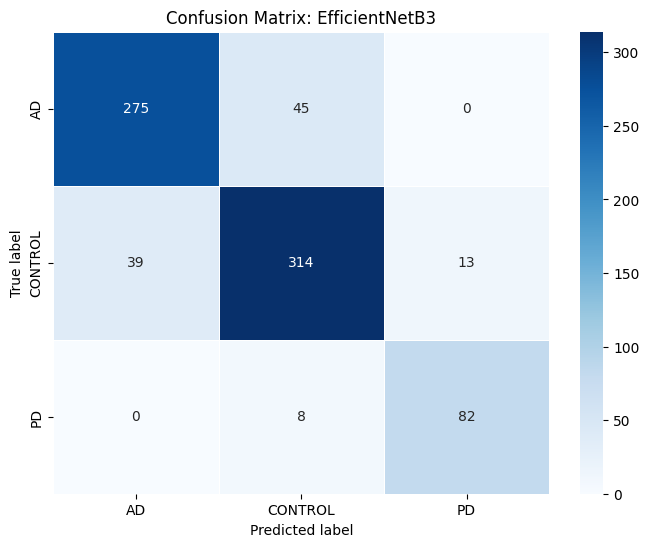

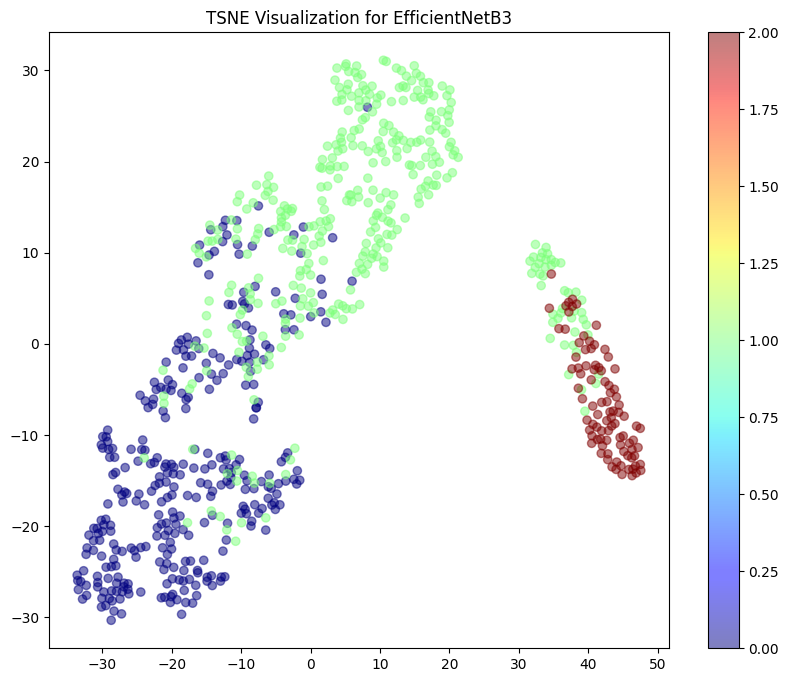

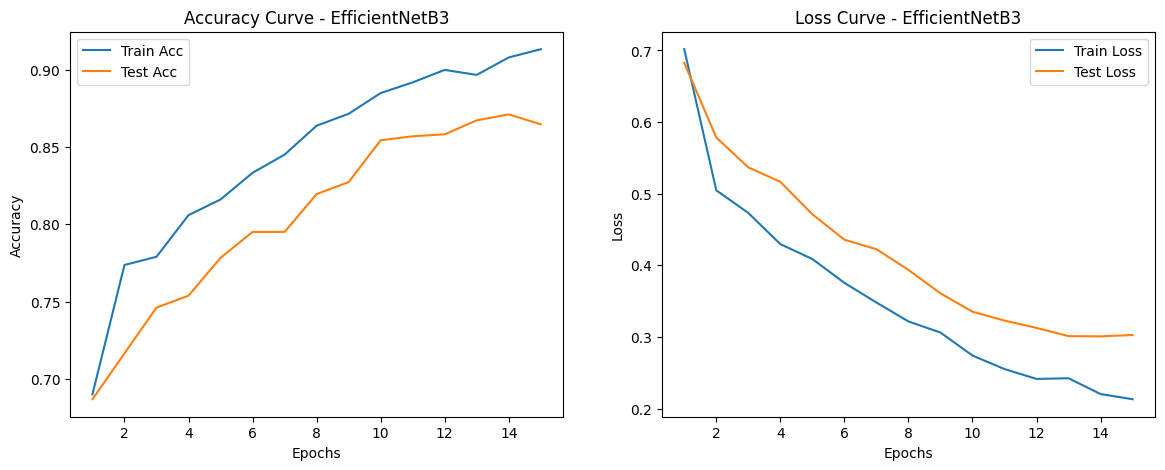


==== Training DenseNet ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 165MB/s] 


Epoch 1/15 | Train Loss: 0.4996 | Train Acc: 0.7868 | Val Loss: 0.5455 | Val Acc: 0.7242 | Test Loss: 0.5179 | Test Acc: 0.7539
Epoch 2/15 | Train Loss: 0.3790 | Train Acc: 0.8290 | Val Loss: 0.4628 | Val Acc: 0.7861 | Test Loss: 0.4372 | Test Acc: 0.8015
Epoch 3/15 | Train Loss: 0.2995 | Train Acc: 0.8723 | Val Loss: 0.3503 | Val Acc: 0.8454 | Test Loss: 0.3438 | Test Acc: 0.8479
Epoch 4/15 | Train Loss: 0.2403 | Train Acc: 0.9054 | Val Loss: 0.3260 | Val Acc: 0.8582 | Test Loss: 0.3115 | Test Acc: 0.8750
Epoch 5/15 | Train Loss: 0.1909 | Train Acc: 0.9259 | Val Loss: 0.3017 | Val Acc: 0.8789 | Test Loss: 0.3012 | Test Acc: 0.8802
Epoch 6/15 | Train Loss: 0.1528 | Train Acc: 0.9441 | Val Loss: 0.2184 | Val Acc: 0.9162 | Test Loss: 0.2001 | Test Acc: 0.9175
Epoch 7/15 | Train Loss: 0.1169 | Train Acc: 0.9573 | Val Loss: 0.2163 | Val Acc: 0.9137 | Test Loss: 0.2099 | Test Acc: 0.9111
Epoch 8/15 | Train Loss: 0.0987 | Train Acc: 0.9634 | Val Loss: 0.1781 | Val Acc: 0.9304 | Test Loss: 0.

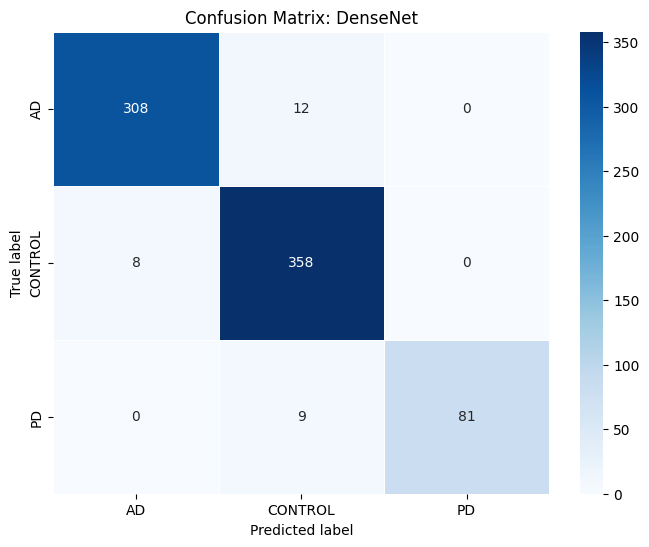

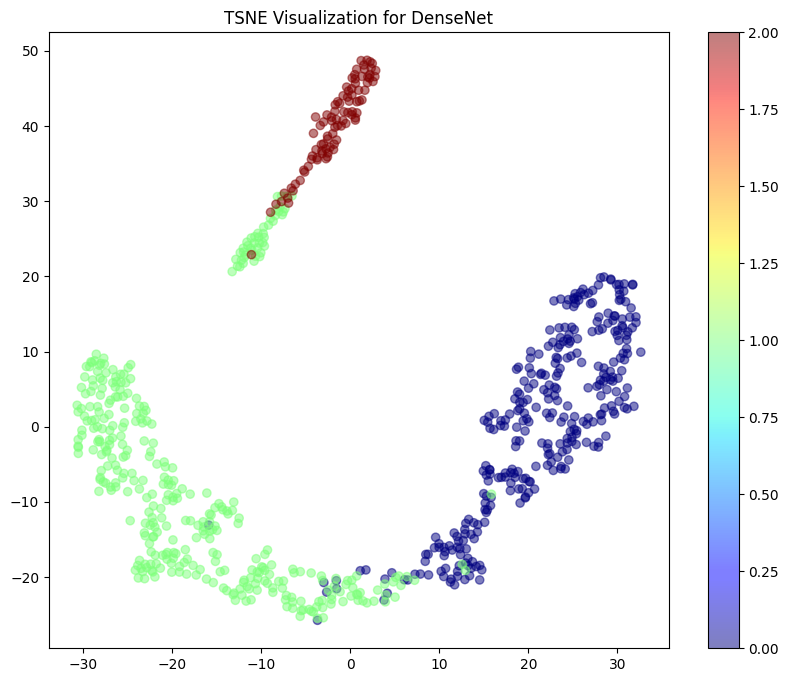

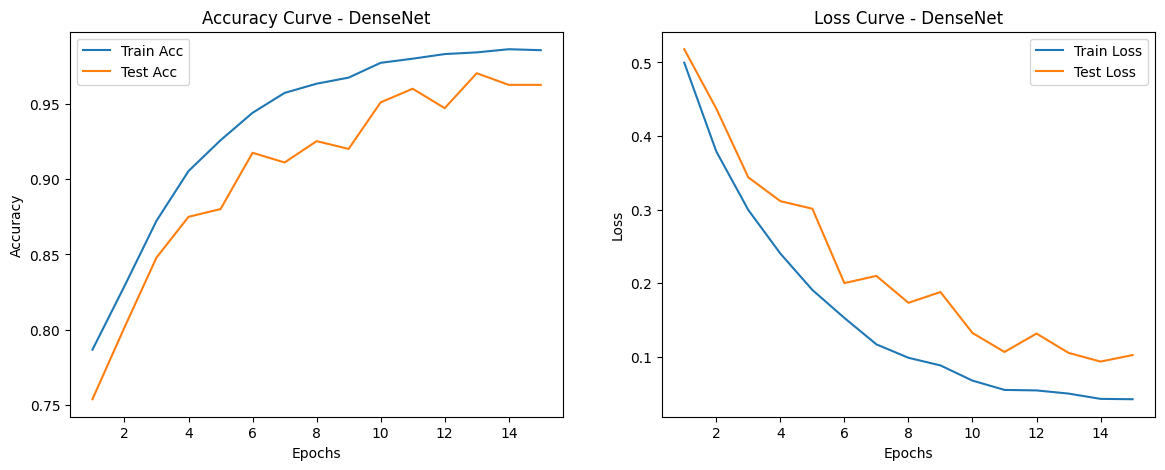


==== Training InceptionV3 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:01<00:00, 57.9MB/s] 


RuntimeError: Calculated padded input size per channel: (3 x 3). Kernel size: (5 x 5). Kernel size can't be greater than actual input size

In [3]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import confusion_matrix, cohen_kappa_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import seaborn as sns
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------- Data Transforms ----------------------
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ---------------------- Dataset Paths ----------------------
train_dir = "/kaggle/working/split_dataset/train"
val_dir = "/kaggle/working/split_dataset/val"
test_dir = "/kaggle/working/split_dataset/test"

# ---------------------- Load Datasets ----------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# ---------------------- Weighted Sampler ----------------------
targets = [label for _, label in train_dataset.imgs]
class_sample_counts = np.bincount(targets)
weights = 1. / class_sample_counts
samples_weights = weights[targets]
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

# ---------------------- Data Loaders ----------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ---------------------- Model Definitions ----------------------
def create_model(model_name, num_classes):
     if model_name == 'InceptionV3':
        model = models.inception_v3(pretrained=True)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

     elif model_name == 'VGG16':
        model = models.vgg16(pretrained=True)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

     elif model_name == 'ResNet18':
        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

     elif model_name == 'ResNet50':
        model = models.resnet50(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

     elif model_name == 'EfficientNetB3':
        model = models.efficientnet_b3(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

     elif model_name == 'DenseNet':
        model = models.densenet121(pretrained=True)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

  

     return model.to(device)

# ---------------------- Evaluation Function ----------------------
def evaluate(loader, model, criterion):
    model.eval()
    correct, total, total_loss = 0, 0, 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return correct / total, total_loss / total, np.array(all_preds), np.array(all_labels)

# ---------------------- Training Loop ----------------------
def train_model(model_name, model, criterion, optimizer, scheduler, num_epochs=15):
    train_losses, val_losses, test_losses = [], [], []
    train_accs, val_accs, test_accs = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects, total_train = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * images.size(0)
            running_corrects += (preds == labels).sum().item()
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects / total_train
        val_acc, val_loss, val_preds, val_labels = evaluate(val_loader, model, criterion)
        test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, model, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

        scheduler.step()

    return model, train_losses, val_losses, test_losses, train_accs, val_accs, test_accs, test_preds, test_labels

# ---------------------- Confusion Matrix ----------------------
def plot_confusion_matrix(test_labels, test_preds, classes, model_name):
    cm = confusion_matrix(test_labels, test_preds)
    df_cm = pd.DataFrame(cm, index=classes, columns=classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# ---------------------- TSNE Visualization ----------------------
def plot_tsne(model, test_loader, model_name):
    model.eval()
    features, labels = [], []

    with torch.no_grad():
        for images, lbls in test_loader:
            images = images.to(device)
            outputs = model(images)
            features.append(outputs.cpu().numpy())
            labels.append(lbls.cpu().numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    tsne = TSNE(n_components=2, random_state=0)
    tsne_results = tsne.fit_transform(features)

    plt.figure(figsize=(10, 8))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='jet', alpha=0.5)
    plt.title(f"TSNE Visualization for {model_name}")
    plt.colorbar()
    plt.show()

# ---------------------- Plot Accuracy & Loss Curves ----------------------
def plot_curves(train_accs,test_accs, train_losses, test_losses, model_name):
    epochs = range(1, len(train_accs)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accs, label='Train Acc')
   
    plt.plot(epochs, test_accs, label='Test Acc')
    plt.title(f"Accuracy Curve - {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss')
   
    plt.plot(epochs, test_losses, label='Test Loss')
    plt.title(f"Loss Curve - {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

# ---------------------- Training and Evaluating Each Model ----------------------
model_names = ['VGG16', 'ResNet18', 'ResNet50', 'EfficientNetB3', 'DenseNet', 'InceptionV3']
results = {}

for model_name in model_names:
    print(f"\n==== Training {model_name} ====")
    model = create_model(model_name, len(train_dataset.classes))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

    model, train_losses, val_losses, test_losses, train_accs, val_accs, test_accs, test_preds, test_labels = train_model(
        model_name, model, criterion, optimizer, scheduler, num_epochs=15)

    precision = precision_score(test_labels, test_preds, average='weighted')
    recall = recall_score(test_labels, test_preds, average='weighted')
    f1 = f1_score(test_labels, test_preds, average='weighted')
    kappa = cohen_kappa_score(test_labels, test_preds)

    results[model_name] = {
        'train_acc': train_accs[-1], 'val_acc': val_accs[-1], 'test_acc': test_accs[-1],
        'precision': precision, 'recall': recall, 'f1': f1, 'kappa': kappa
    }

    print(f"\nResults for {model_name}:")
    print(f"Train Accuracy: {train_accs[-1]:.4f}, Val Accuracy: {val_accs[-1]:.4f}, Test Accuracy: {test_accs[-1]:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, Cohen's Kappa: {kappa:.4f}")

    plot_confusion_matrix(test_labels, test_preds, test_dataset.classes, model_name)
    plot_tsne(model, test_loader, model_name)
    plot_curves(train_accs,test_accs, train_losses,test_losses, model_name)

# ---------------------- Display Results ----------------------
print("\nOverall Results:")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f" Train Acc: {metrics['train_acc']:.4f} | "
          f"Val Acc: {metrics['val_acc']:.4f} | "
          f"Test Acc: {metrics['test_acc']:.4f} | "
          f"Precision: {metrics['precision']:.4f} | "
          f"Recall: {metrics['recall']:.4f} | "
          f"F1 Score: {metrics['f1']:.4f} | "
          f"Kappa: {metrics['kappa']:.4f}")
    print("-" * 40)


Epoch 1/15 | Train Loss: 0.5384 | Train Acc: 0.7573 | Val Loss: 0.5278 | Val Acc: 0.7539 | Test Loss: 0.4905 | Test Acc: 0.7809
Epoch 2/15 | Train Loss: 0.3968 | Train Acc: 0.8209 | Val Loss: 0.4694 | Val Acc: 0.7912 | Test Loss: 0.4272 | Test Acc: 0.8119
Epoch 3/15 | Train Loss: 0.2982 | Train Acc: 0.8802 | Val Loss: 0.3903 | Val Acc: 0.8299 | Test Loss: 0.3446 | Test Acc: 0.8570
Epoch 4/15 | Train Loss: 0.2465 | Train Acc: 0.8986 | Val Loss: 0.3512 | Val Acc: 0.8544 | Test Loss: 0.3231 | Test Acc: 0.8686
Epoch 5/15 | Train Loss: 0.1799 | Train Acc: 0.9255 | Val Loss: 0.2689 | Val Acc: 0.8866 | Test Loss: 0.2570 | Test Acc: 0.8892
Epoch 6/15 | Train Loss: 0.1327 | Train Acc: 0.9497 | Val Loss: 0.2150 | Val Acc: 0.9085 | Test Loss: 0.2017 | Test Acc: 0.9137
Epoch 7/15 | Train Loss: 0.1154 | Train Acc: 0.9550 | Val Loss: 0.2001 | Val Acc: 0.9085 | Test Loss: 0.1951 | Test Acc: 0.9214
Epoch 8/15 | Train Loss: 0.0945 | Train Acc: 0.9660 | Val Loss: 0.1881 | Val Acc: 0.9330 | Test Loss: 0.

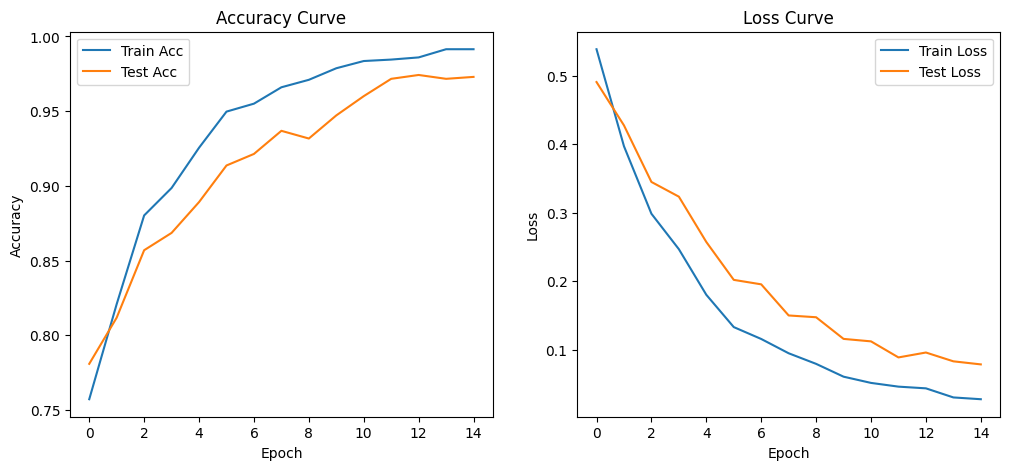

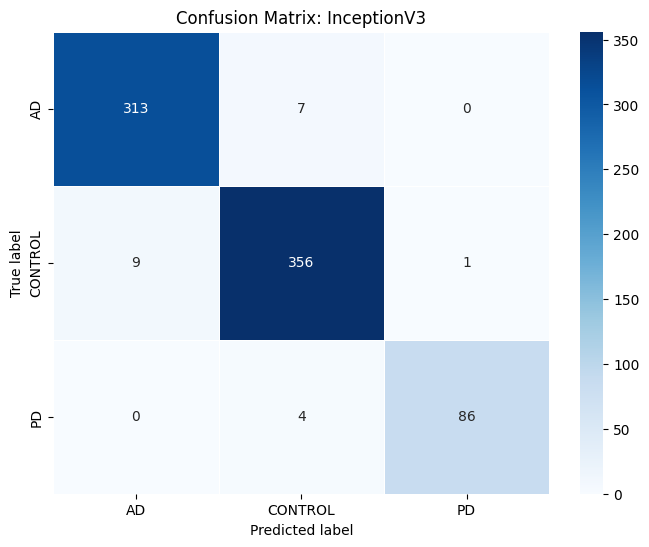

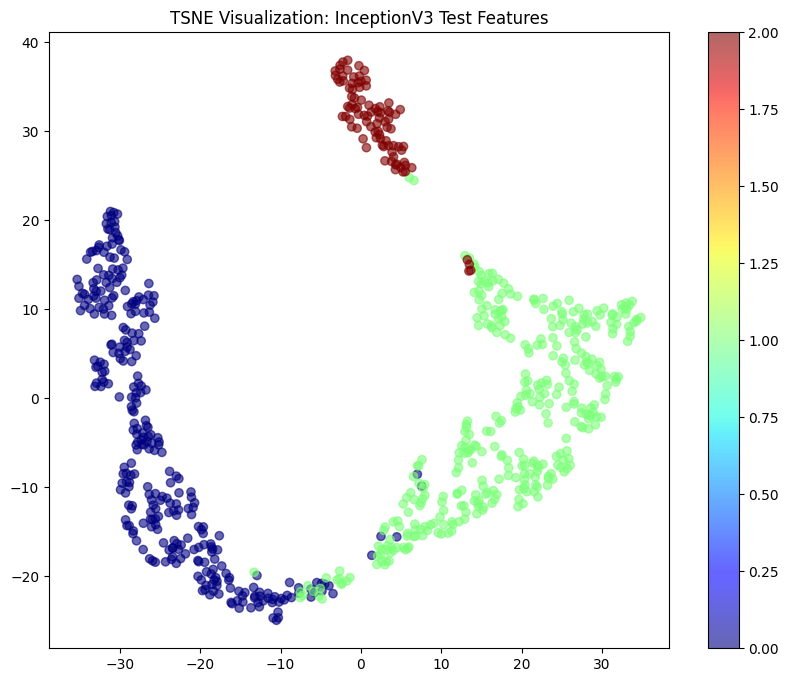


=== InceptionV3 Evaluation Metrics ===
Train Accuracy: 0.9982 | Precision: 0.9982 | Recall: 0.9982 | F1 Score: 0.9982 | Cohen's Kappa: 0.9973
Val Accuracy:   0.9626 | Precision: 0.9628 | Recall: 0.9626 | F1 Score: 0.9627 | Cohen's Kappa: 0.9371
Test Accuracy:  0.9729 | Precision: 0.9730 | Recall: 0.9729 | F1 Score: 0.9729 | Cohen's Kappa: 0.9544

Metrics saved to /kaggle/working/inceptionv3_metrics_summary.csv


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------- Transforms ----------------------
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ---------------------- Dataset Paths ----------------------
train_dir = "/kaggle/working/split_dataset/train"
val_dir = "/kaggle/working/split_dataset/val"
test_dir = "/kaggle/working/split_dataset/test"

# ---------------------- Load Datasets ----------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# ---------------------- Weighted Sampler ----------------------
targets = [label for _, label in train_dataset.imgs]
class_sample_counts = np.bincount(targets)
weights = 1. / class_sample_counts
samples_weights = weights[targets]
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

# ---------------------- Data Loaders ----------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ---------------------- Model ----------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=True)
num_classes = len(train_dataset.classes)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ---------------------- Loss and Optimizer ----------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# ---------------------- Evaluation Function ----------------------
def evaluate(loader, model, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    avg_loss = total_loss / total
    return acc, avg_loss, np.array(all_preds), np.array(all_labels)

# ---------------------- Training Loop ----------------------
num_epochs = 15
train_losses, val_losses, test_losses = [], [], []
train_accs, val_accs, test_accs = [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects / total_train
    val_acc, val_loss, _, _ = evaluate(val_loader, model, criterion)
    test_acc, test_loss, _, _ = evaluate(test_loader, model, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    scheduler.step()

# ---------------------- Accuracy & Loss Curves ----------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_accs, label='Train Acc')

plt.plot(test_accs, label='Test Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(False)  # Remove background boxes

plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')

plt.plot(test_losses, label='Test Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.show()

# ---------------------- Confusion Matrix ----------------------
test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, model, criterion)
cm = confusion_matrix(test_labels, test_preds)
df_cm = pd.DataFrame(cm, index=train_dataset.classes, columns=train_dataset.classes)
plt.figure(figsize=(8,6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Confusion Matrix: InceptionV3")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# ---------------------- TSNE Visualization ----------------------
model.eval()
features, labels = [], []
with torch.no_grad():
    for images, lbls in test_loader:
        images = images.to(device)
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        features.append(outputs.cpu().numpy())
        labels.append(lbls.cpu().numpy())

features = np.concatenate(features)
labels = np.concatenate(labels)

tsne = TSNE(n_components=2, random_state=0)
tsne_results = tsne.fit_transform(features)

plt.figure(figsize=(10,8))
plt.scatter(tsne_results[:,0], tsne_results[:,1], c=labels, cmap='jet', alpha=0.6)
plt.title('TSNE Visualization: InceptionV3 Test Features')
plt.colorbar()
plt.show()

# ---------------------- Final Evaluation Metrics ----------------------
train_acc, train_loss, train_preds, train_labels = evaluate(train_loader, model, criterion)
val_acc, val_loss, val_preds, val_labels = evaluate(val_loader, model, criterion)
test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, model, criterion)

# Metrics calculation
train_precision = precision_score(train_labels, train_preds, average='weighted')
train_recall = recall_score(train_labels, train_preds, average='weighted')
train_f1 = f1_score(train_labels, train_preds, average='weighted')
train_kappa = cohen_kappa_score(train_labels, train_preds)

val_precision = precision_score(val_labels, val_preds, average='weighted')
val_recall = recall_score(val_labels, val_preds, average='weighted')
val_f1 = f1_score(val_labels, val_preds, average='weighted')
val_kappa = cohen_kappa_score(val_labels, val_preds)

test_precision = precision_score(test_labels, test_preds, average='weighted')
test_recall = recall_score(test_labels, test_preds, average='weighted')
test_f1 = f1_score(test_labels, test_preds, average='weighted')
test_kappa = cohen_kappa_score(test_labels, test_preds)

# Print metrics
print("\n=== InceptionV3 Evaluation Metrics ===")
print(f"Train Accuracy: {train_acc:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | F1 Score: {train_f1:.4f} | Cohen's Kappa: {train_kappa:.4f}")
print(f"Val Accuracy:   {val_acc:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1 Score: {val_f1:.4f} | Cohen's Kappa: {val_kappa:.4f}")
print(f"Test Accuracy:  {test_acc:.4f} | Precision: {test_precision:.4f} | Recall: {test_recall:.4f} | F1 Score: {test_f1:.4f} | Cohen's Kappa: {test_kappa:.4f}")

# ---------------------- Save metrics to CSV ----------------------
results_df = pd.DataFrame({
    "Model": ["InceptionV3"],
    "Train Accuracy": [train_acc],
    "Train Precision": [train_precision],
    "Train Recall": [train_recall],
    "Train F1 Score": [train_f1],
    "Train Kappa": [train_kappa],
    "Val Accuracy": [val_acc],
    "Val Precision": [val_precision],
    "Val Recall": [val_recall],
    "Val F1 Score": [val_f1],
    "Val Kappa": [val_kappa],
    "Test Accuracy": [test_acc],
    "Test Precision": [test_precision],
    "Test Recall": [test_recall],
    "Test F1 Score": [test_f1],
    "Test Kappa": [test_kappa],
})

results_df.to_csv("/kaggle/working/inceptionv3_metrics_summary.csv", index=False)
print("\nMetrics saved to /kaggle/working/inceptionv3_metrics_summary.csv")
